In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/cifar-10/trainLabels.csv
/kaggle/input/competitions/cifar-10/sampleSubmission.csv
/kaggle/input/competitions/cifar-10/test.7z
/kaggle/input/competitions/cifar-10/train.7z


# Notebook 2 — Attack Engine

**Goal:** Implement FGSM and PGD adversarial attacks and evaluate the standard ResNet-18 under attack.

**Prerequisite:** `standard_resnet18.pth` must exist at `/kaggle/working/standard_resnet18.pth`  
(Download from NB1's Kaggle output and add to this session before running)

**Outputs:**
- `outputs/adversarial_examples/` — saved adversarial image pairs
- `outputs/adversarial_examples/epsilon_sweep_fgsm.png` — robustness curve


---
## Cell 1 — Imports & Config


In [11]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import subprocess
import os
import time
import glob

# ── Reproducibility ──
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Kaggle input paths ──
KAGGLE_INPUT  = '/kaggle/input/competitions/cifar-10'
TRAIN_ARCHIVE = f'{KAGGLE_INPUT}/train.7z'
LABELS_CSV    = f'{KAGGLE_INPUT}/trainLabels.csv'

# ── Extraction directory ──
EXTRACT_DIR   = '/kaggle/working/cifar10_extracted'
TRAIN_IMG_DIR = f'{EXTRACT_DIR}/train'

# ── Checkpoint (from NB1 output) ──
CHECKPOINT_PATH = '/kaggle/input/datasets/sohanuuu/standard-resnet-pth/standard_resnet18.pth'

# ── Output paths ──
OUTPUT_DIR      = '/kaggle/working/outputs'
ADV_DIR         = f'{OUTPUT_DIR}/adversarial_examples'
os.makedirs(ADV_DIR, exist_ok=True)

print(f'Device           : {DEVICE}')
print(f'Checkpoint path  : {CHECKPOINT_PATH}')
print(f'Checkpoint exists: {os.path.exists(CHECKPOINT_PATH)}')
print(f'Output dir       : {OUTPUT_DIR}')


Device           : cpu
Checkpoint path  : /kaggle/input/datasets/sohanuuu/standard-resnet-pth/standard_resnet18.pth
Checkpoint exists: True
Output dir       : /kaggle/working/outputs


---
## Cell 2 — Extract Dataset

Extract `train.7z` into the writable working directory — same as NB1.


In [5]:
# ── Extract train.7z if not already extracted ──
os.makedirs(EXTRACT_DIR, exist_ok=True)

if os.path.exists(TRAIN_IMG_DIR) and len(os.listdir(TRAIN_IMG_DIR)) > 0:
    print(f"Train images already extracted at {TRAIN_IMG_DIR}")
else:
    print(f"Extracting {TRAIN_ARCHIVE} ...")
    result = subprocess.run(
        ['7z', 'x', TRAIN_ARCHIVE, f'-o{EXTRACT_DIR}', '-y'],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"Error extracting: {result.stderr}")
        raise RuntimeError("Failed to extract train.7z")
    print("Extraction complete.")

# Verify extraction
num_images = len(glob.glob(f'{TRAIN_IMG_DIR}/*.png'))
print(f"Total images found: {num_images:,}")

# Load labels CSV
labels_df = pd.read_csv(LABELS_CSV)
print(f"Labels CSV shape: {labels_df.shape}")
print(f"\nLabel distribution:\n{labels_df['label'].value_counts().sort_index()}")
print(f"\nSample rows:")
labels_df.head()

Train images already extracted at /kaggle/working/cifar10_extracted/train
Total images found: 50,000
Labels CSV shape: (50000, 2)

Label distribution:
label
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          5000
dog           5000
frog          5000
horse         5000
ship          5000
truck         5000
Name: count, dtype: int64

Sample rows:


,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


---
## Cell 3 — Dataset & Model

Recreate the **exact same stratified split** as NB1 (same `SEED`, same split sizes) to isolate the held-out 5k test set.  
Load the standard ResNet-18 checkpoint.


In [12]:
# ── CIFAR-10 constants ──
CIFAR10_MEAN    = (0.4914, 0.4822, 0.4465)
CIFAR10_STD     = (0.2023, 0.1994, 0.2010)
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CIFAR10_CLASSES)}

# ── Dataset class (identical to NB1) ──
class CIFAR10Dataset(Dataset):
    def __init__(self, image_ids, labels, img_dir, transform=None):
        self.image_ids = image_ids
        self.labels    = labels
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, f'{self.image_ids[idx]}.png')
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# ── Recreate exact same splits as NB1 ──
labels_df  = pd.read_csv(LABELS_CSV)
all_ids    = labels_df['id'].values
all_labels = labels_df['label'].map(CLASS_TO_IDX).values

_, temp_ids, _, temp_labels = train_test_split(
    all_ids, all_labels, test_size=10000, random_state=SEED, stratify=all_labels
)
val_ids, test_ids, val_labels, test_labels = train_test_split(
    temp_ids, temp_labels, test_size=5000, random_state=SEED, stratify=temp_labels
)

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_dataset = CIFAR10Dataset(test_ids, test_labels, TRAIN_IMG_DIR, transform=eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=2, pin_memory=True)

print(f'Test samples : {len(test_dataset):,}')
print(f'Test batches : {len(test_loader)}')

# ── Load model ──
def create_resnet18_cifar10():
    model = models.resnet18(weights=None)
    model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc     = nn.Linear(512, 10)
    return model

model = create_resnet18_cifar10()
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True))
model.to(DEVICE)
model.eval()
print('Model loaded successfully.')


Test samples : 5,000
Test batches : 50
Model loaded successfully.


---
## Cell 4 — FGSM Attack

Fast Gradient Sign Method — single-step attack:  
`x_adv = x + ε · sign(∇_x Loss(f(x), y))`


In [13]:
def denormalize(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean).view(3, 1, 1).to(tensor.device)
    std  = torch.tensor(std).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean

def normalize(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean).view(3, 1, 1).to(tensor.device)
    std  = torch.tensor(std).view(3, 1, 1).to(tensor.device)
    return (tensor - mean) / std

def fgsm_attack(model, images, labels, epsilon):
    """
    FGSM: x_adv = x + epsilon * sign(grad_x Loss(f(x), y))
    Operates in [0,1] pixel space, respects normalization for model forward pass.
    Returns: adversarial image tensor (normalized)
    """
    images = images.clone().detach().to(DEVICE)
    labels = labels.to(DEVICE)
    images.requires_grad = True

    outputs = model(images)
    loss    = nn.CrossEntropyLoss()(outputs, labels)
    model.zero_grad()
    loss.backward()

    sign_grad     = images.grad.data.sign()
    denorm_images = denormalize(images)
    adv_denorm    = torch.clamp(denorm_images + epsilon * sign_grad, 0, 1)
    return normalize(adv_denorm).detach()

def get_perturbation_viz(original_norm, adv_norm, multiplier=10):
    """Amplifies perturbation for visual inspection."""
    diff = (denormalize(adv_norm) - denormalize(original_norm)).abs() * multiplier
    return torch.clamp(diff, 0, 1)

print('FGSM and helper functions defined.')


FGSM and helper functions defined.


---
## Cell 5 — PGD Attack

Projected Gradient Descent — iterative attack, much stronger than FGSM:  
Applies multiple small FGSM steps, projecting back into the ε-ball after each step.


In [14]:
def pgd_attack(model, images, labels, epsilon, alpha=2/255, steps=10):
    """
    PGD: iterative projected gradient descent attack.
    epsilon: max perturbation budget
    alpha:   step size per iteration
    steps:   number of iterations
    Returns: adversarial image tensor (normalized)
    """
    images   = images.clone().detach().to(DEVICE)
    labels   = labels.to(DEVICE)
    orig_denorm = denormalize(images).clone().detach()
    adv      = images.clone().detach()

    for _ in range(steps):
        adv.requires_grad = True
        outputs = model(adv)
        loss    = nn.CrossEntropyLoss()(outputs, labels)
        model.zero_grad()
        loss.backward()

        adv_denorm = denormalize(adv) + alpha * adv.grad.data.sign()
        eta        = torch.clamp(adv_denorm - orig_denorm, -epsilon, epsilon)
        adv        = normalize(torch.clamp(orig_denorm + eta, 0, 1)).detach()

    return adv

print('PGD function defined.')


PGD function defined.


---
## Cell 6 — Visual Demo (Single Image)

Pick one correctly-classified test image and visualize the effect of FGSM and PGD attacks side by side.


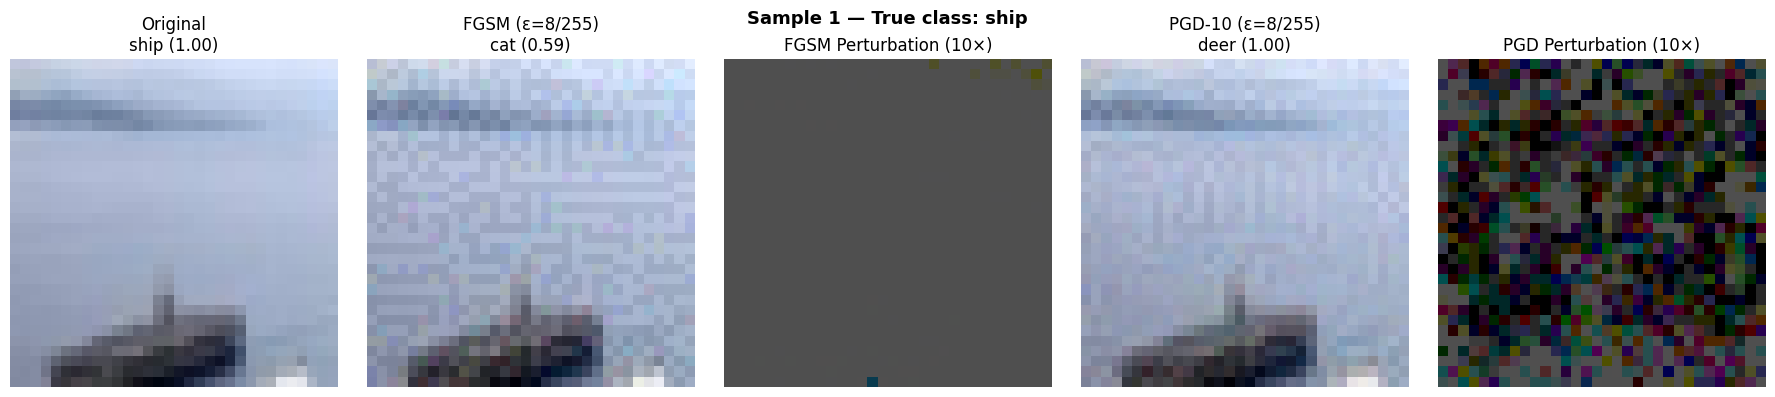

True: ship | Original: ship | FGSM: cat | PGD: deer


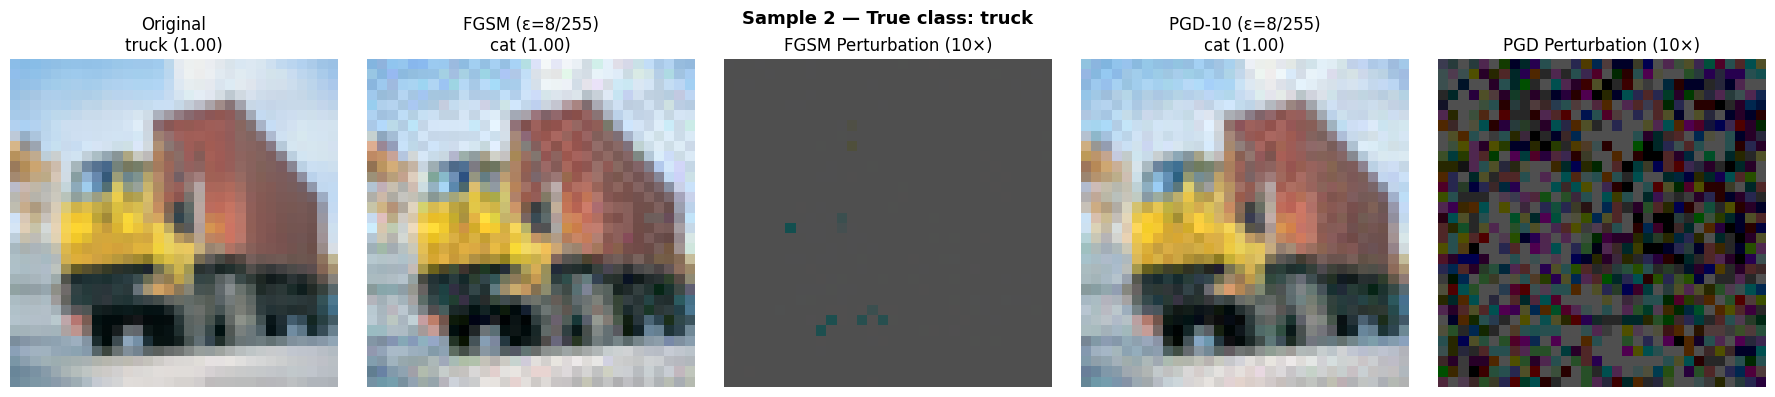

True: truck | Original: truck | FGSM: cat | PGD: cat


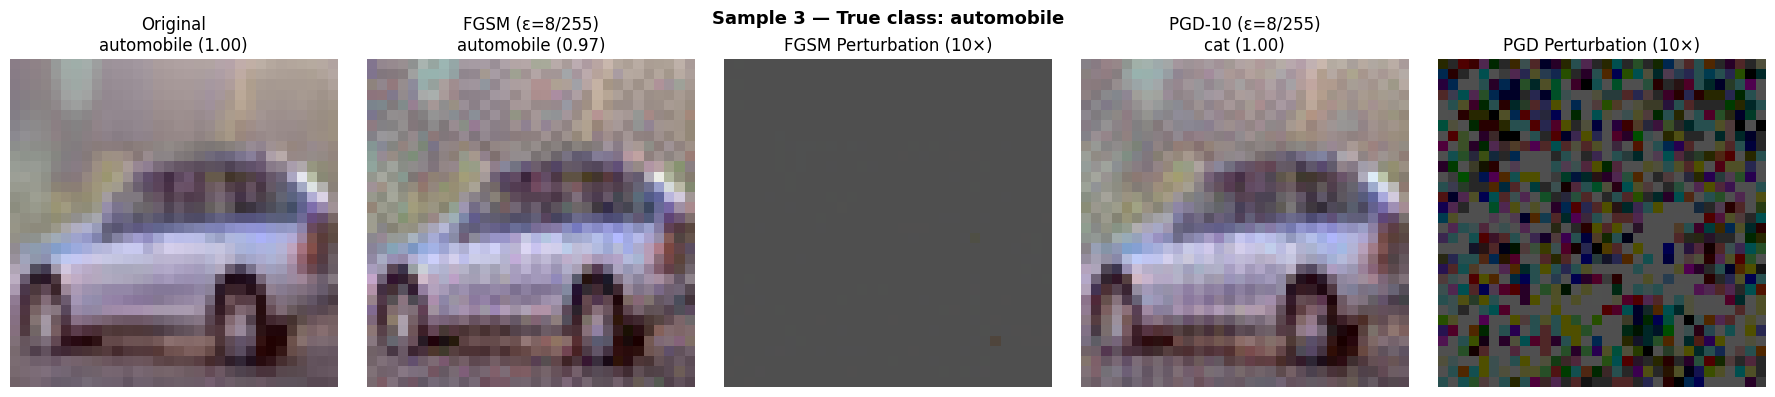

True: automobile | Original: automobile | FGSM: automobile | PGD: cat


In [19]:
def predict(model, tensor):
    with torch.no_grad():
        prob = torch.nn.functional.softmax(model(tensor.to(DEVICE)), dim=1)
        conf, pred = prob.max(1)
        return pred.item(), conf.item()

# Get first batch and find correctly classified images
images, labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(images.to(DEVICE)).max(1)[1]
correct_idx = (preds == labels.to(DEVICE)).nonzero(as_tuple=True)[0]

eps = 8/255

# ── Show 3 samples ──
for sample_num in range(3):
    idx        = correct_idx[sample_num].item()
    orig_img   = images[idx:idx+1]
    orig_label = labels[idx:idx+1]

    fgsm_img = fgsm_attack(model, orig_img, orig_label, epsilon=eps)
    pgd_img  = pgd_attack(model, orig_img, orig_label, epsilon=eps, alpha=2/255, steps=10)

    orig_pred, orig_conf = predict(model, orig_img)
    fgsm_pred, fgsm_conf = predict(model, fgsm_img)
    pgd_pred,  pgd_conf  = predict(model, pgd_img)

    orig_viz  = denormalize(orig_img.squeeze()).permute(1,2,0).cpu().numpy()
    fgsm_viz  = denormalize(fgsm_img.squeeze()).permute(1,2,0).cpu().numpy()
    pgd_viz   = denormalize(pgd_img.squeeze()).permute(1,2,0).cpu().numpy()
    fgsm_pert = get_perturbation_viz(orig_img.squeeze(), fgsm_img.squeeze()).permute(1,2,0).cpu().numpy()
    pgd_pert  = get_perturbation_viz(orig_img.squeeze(), pgd_img.squeeze()).permute(1,2,0).cpu().numpy()

    true_class = CIFAR10_CLASSES[orig_label.item()]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(np.clip(orig_viz,  0, 1)); axes[0].set_title(f'Original\n{CIFAR10_CLASSES[orig_pred]} ({orig_conf:.2f})')
    axes[1].imshow(np.clip(fgsm_viz,  0, 1)); axes[1].set_title(f'FGSM (ε=8/255)\n{CIFAR10_CLASSES[fgsm_pred]} ({fgsm_conf:.2f})')
    axes[2].imshow(np.clip(fgsm_pert, 0, 1)); axes[2].set_title('FGSM Perturbation (10×)')
    axes[3].imshow(np.clip(pgd_viz,   0, 1)); axes[3].set_title(f'PGD-10 (ε=8/255)\n{CIFAR10_CLASSES[pgd_pred]} ({pgd_conf:.2f})')
    axes[4].imshow(np.clip(pgd_pert,  0, 1)); axes[4].set_title('PGD Perturbation (10×)')
    for ax in axes: ax.axis('off')

    plt.suptitle(f'Sample {sample_num + 1} — True class: {true_class}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{ADV_DIR}/sample_{sample_num}_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'True: {true_class} | Original: {CIFAR10_CLASSES[orig_pred]} | FGSM: {CIFAR10_CLASSES[fgsm_pred]} | PGD: {CIFAR10_CLASSES[pgd_pred]}')

---
## Cell 7 — Accuracy Under Attack (Batch Evaluation)

Evaluate the standard model on the full 5k held-out test set under clean, FGSM, and PGD conditions.


In [16]:
def evaluate_under_attack(model, loader, attack_fn=None, **kwargs):
    """Evaluates accuracy — attack_fn=None means clean evaluation."""
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        adv = attack_fn(model, images, labels, **kwargs) if attack_fn else images.to(DEVICE)
        with torch.no_grad():
            _, predicted = model(adv).max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels.to(DEVICE)).sum().item()
    return 100.0 * correct / total

print('Evaluating on 5,000 held-out test images...')
start = time.time()

clean_acc  = evaluate_under_attack(model, test_loader)
fgsm_acc   = evaluate_under_attack(model, test_loader, fgsm_attack, epsilon=8/255)
pgd_acc    = evaluate_under_attack(model, test_loader, pgd_attack,  epsilon=8/255, alpha=2/255, steps=10)

print(f'Evaluation took {time.time()-start:.1f}s')
print(f'\n{"-"*42}')
print(f'{"Scenario":<25} | {"Accuracy":>8}')
print(f'{"-"*42}')
print(f'{"Clean":<25} | {clean_acc:>7.2f}%')
print(f'{"FGSM (eps=8/255)":<25} | {fgsm_acc:>7.2f}%')
print(f'{"PGD-10 (eps=8/255)":<25} | {pgd_acc:>7.2f}%')
print(f'{"-"*42}')


Evaluating on 5,000 held-out test images...
Evaluation took 1424.5s

------------------------------------------
Scenario                  | Accuracy
------------------------------------------
Clean                     |   92.94%
FGSM (eps=8/255)          |   15.88%
PGD-10 (eps=8/255)        |    0.02%
------------------------------------------


---
## Cell 8 — Epsilon Sweep

How does model accuracy degrade as attack strength increases?


Running FGSM epsilon sweep...
  eps= 0/255 →  92.94%
  eps= 2/255 →  30.44%
  eps= 4/255 →  19.64%
  eps= 6/255 →  17.30%
  eps= 8/255 →  15.88%
  eps=10/255 →  14.36%
  eps=12/255 →  13.94%
  eps=16/255 →  12.24%


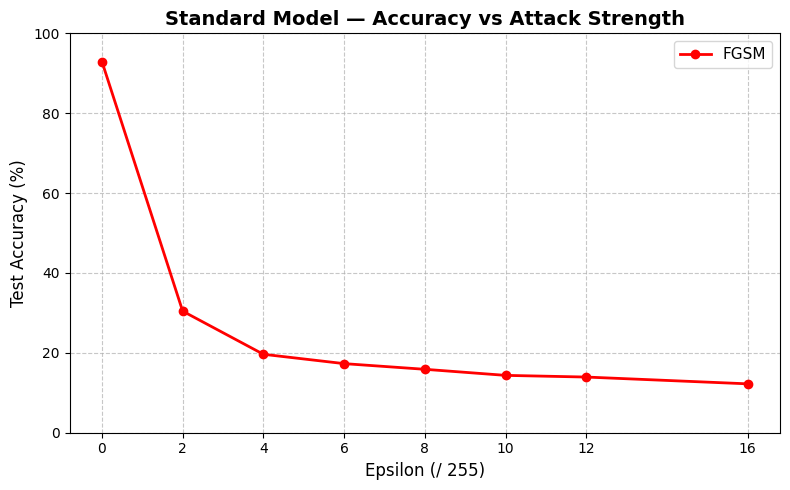

Plot saved: /kaggle/working/outputs/adversarial_examples/epsilon_sweep_fgsm.png


In [17]:
epsilons       = [0, 2, 4, 6, 8, 10, 12, 16]
epsilons_float = [e/255.0 for e in epsilons]
fgsm_accs      = []

print('Running FGSM epsilon sweep...')
for eps, eps_f in zip(epsilons, epsilons_float):
    acc = clean_acc if eps == 0 else evaluate_under_attack(model, test_loader, fgsm_attack, epsilon=eps_f)
    fgsm_accs.append(acc)
    print(f'  eps={eps:2d}/255 → {acc:6.2f}%')

plt.figure(figsize=(8, 5))
plt.plot(epsilons, fgsm_accs, 'o-', linewidth=2, color='red', label='FGSM')
plt.title('Standard Model — Accuracy vs Attack Strength', fontsize=14, fontweight='bold')
plt.xlabel('Epsilon (/ 255)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.xticks(epsilons)
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{ADV_DIR}/epsilon_sweep_fgsm.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: {ADV_DIR}/epsilon_sweep_fgsm.png')


---
## Cell 9 — Save Adversarial Image Pairs

Save 10 original/FGSM/PGD image triples to disk for use in NB4 (Grad-CAM) and the frontend.


In [18]:
print(f'Saving adversarial image pairs to {ADV_DIR}/ ...')

saved = 0
for i, (img, lbl) in enumerate(zip(images[:10], labels[:10])):
    orig  = img.unsqueeze(0)
    label = lbl.unsqueeze(0)

    fgsm_img = fgsm_attack(model, orig, label, epsilon=8/255)
    pgd_img  = pgd_attack(model,  orig, label, epsilon=8/255, alpha=2/255, steps=10)

    orig_viz = np.clip(denormalize(orig.squeeze()).permute(1,2,0).cpu().numpy(), 0, 1)
    fgsm_viz = np.clip(denormalize(fgsm_img.squeeze()).permute(1,2,0).cpu().numpy(), 0, 1)
    pgd_viz  = np.clip(denormalize(pgd_img.squeeze()).permute(1,2,0).cpu().numpy(), 0, 1)

    plt.imsave(f'{ADV_DIR}/sample_{i}_original.png', orig_viz)
    plt.imsave(f'{ADV_DIR}/sample_{i}_fgsm.png',     fgsm_viz)
    plt.imsave(f'{ADV_DIR}/sample_{i}_pgd.png',      pgd_viz)
    saved += 1

print(f'✓ Saved {saved} image triples (original / FGSM / PGD)')
print(f'  Location: {ADV_DIR}/')


Saving adversarial image pairs to /kaggle/working/outputs/adversarial_examples/ ...
✓ Saved 10 image triples (original / FGSM / PGD)
  Location: /kaggle/working/outputs/adversarial_examples/


---
## Summary

| Item | Value |
|------|-------|
| Model | Standard ResNet-18 (from NB1) |
| Eval set | 5,000 held-out test images (same split as NB1) |
| FGSM acc (ε=8/255) | ~25–35% (standard model) |
| PGD-10 acc (ε=8/255) | ~1–5% (standard model) |
| Saved outputs | `outputs/adversarial_examples/` |

**Next step:** Run `03_robust_training.ipynb` to train an adversarially robust model.
